In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load
data = pd.read_csv('Housing.csv')
data

# Encode categorical columns using Label Encoding
label_encoder = LabelEncoder()
categorical_cols = [
    'price', 'mainroad', 'guestroom', 'basement', 'hotwaterheating',
    'airconditioning', 'prefarea', 'furnishingstatus'
]

data.columns

# Encode categorical columns using Label Encoding
label_encoder = LabelEncoder()
categorical_columns = [
    'mainroad', 'guestroom', 'basement', 'hotwaterheating',
    'airconditioning', 'prefarea', 'furnishingstatus'
]

for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

# Split the dataset into features (X) and target variable (y)
X = data.drop(columns=['price'])
y = data['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Function to take inputs and predict the price
def predict_house_price():
    print("Enter the details of the house:")
    area = float(input("Area (in square feet): "))
    bedrooms = int(input("Number of bedrooms: "))
    bathrooms = int(input("Number of bathrooms: "))
    stories = int(input("Number of stories: "))
    mainroad = int(input("Main road access (1 for yes, 0 for no): "))
    guestroom = int(input("Guestroom available (1 for yes, 0 for no): "))
    basement = int(input("Basement available (1 for yes, 0 for no): "))
    hotwaterheating = int(input("Hot water heating available (1 for yes, 0 for no): "))
    airconditioning = int(input("Air conditioning available (1 for yes, 0 for no): "))
    parking = int(input("Number of parking spaces: "))
    prefarea = int(input("Preferred area (1 for yes, 0 for no): "))
    furnishingstatus = int(input("Furnishing status (0 for unfurnished, 1 for semi-furnished, 2 for furnished): "))

    # Create a DataFrame for the input
    input_data = pd.DataFrame([[
        area, bedrooms, bathrooms, stories, mainroad, guestroom, basement,
        hotwaterheating, airconditioning, parking, prefarea, furnishingstatus
    ]], columns=[
        'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
        'basement', 'hotwaterheating', 'airconditioning', 'parking',
        'prefarea', 'furnishingstatus'
    ])

    # Predict the price
    predicted_price = linear_model.predict(input_data)[0]
    print(f"\nPredicted House Price: ₹{predicted_price:,.2f}")

# Call the function
predict_house_price()

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Display the first few predictions
print("Predicted Values:", y_pred[:5])

# Display the corresponding actual values
print("Actual Values:", y_test[:5].values)


# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print("Mean Squared Error (MSE):", mse)
print("R^2 Score:", r2)

# Optional: Display the coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})
print("\nFeature Coefficients:\n", coefficients)

Enter the details of the house:
Area (in square feet): 3000
Number of bedrooms: 1
Number of bathrooms: 1
Number of stories: 1
Main road access (1 for yes, 0 for no): 1
Guestroom available (1 for yes, 0 for no): 1
Basement available (1 for yes, 0 for no): 1
Hot water heating available (1 for yes, 0 for no): 1
Air conditioning available (1 for yes, 0 for no): 1
Number of parking spaces: 1
Preferred area (1 for yes, 0 for no): 1
Furnishing status (0 for unfurnished, 1 for semi-furnished, 2 for furnished): 1

Predicted House Price: ₹5,694,367.99
Predicted Values: [5203691.70963178 7257004.02115475 3062828.59668171 4559591.65374424
 3332932.30559782]
Actual Values: [4060000 6650000 3710000 6440000 2800000]
Mean Squared Error (MSE): 1771751116594.0352
R^2 Score: 0.6494754192267803

Feature Coefficients:
              Feature   Coefficient
0               area  2.358488e+02
1           bedrooms  7.857449e+04
2          bathrooms  1.097117e+06
3            stories  4.062232e+05
4           mai

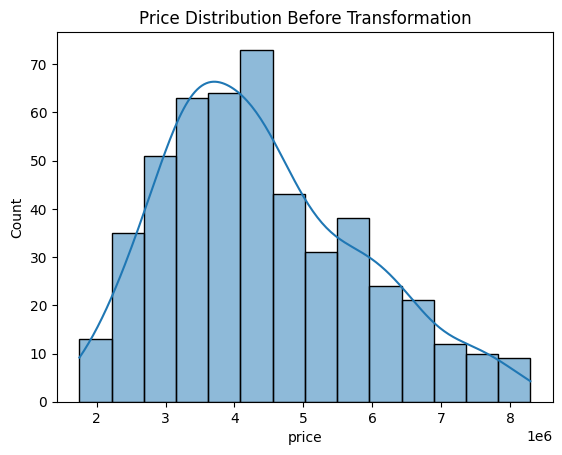

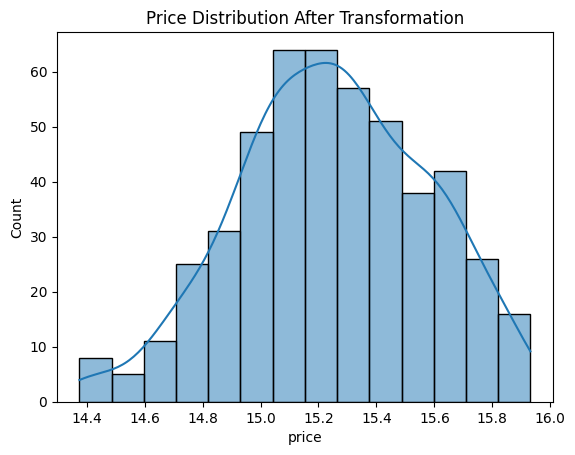

Best Alpha for Ridge Regression: 100
Ridge Regression MSE: 0.04333415685508093
Ridge Regression R^2 Score: 0.6679559247486507
Random Forest MSE: 0.0487161993740648
Random Forest R^2 Score: 0.626716508526574

Feature Importance from Random Forest:
                   Feature  Importance
16          area mainroad    0.281741
14         area bathrooms    0.083283
15           area stories    0.080272
23  area furnishingstatus    0.059594
13          area bedrooms    0.048549


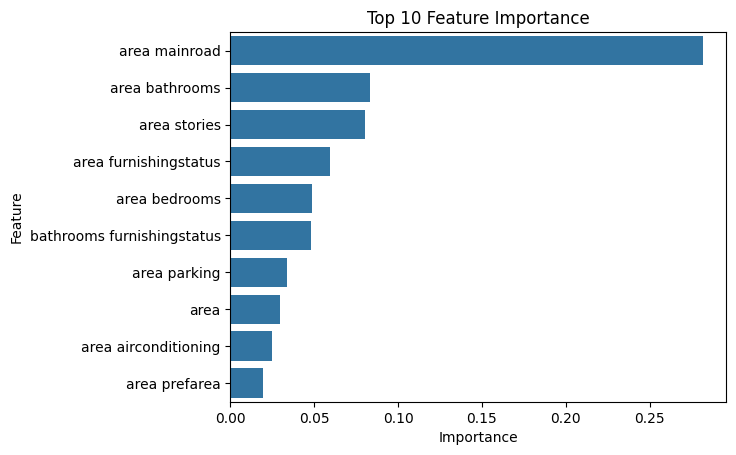

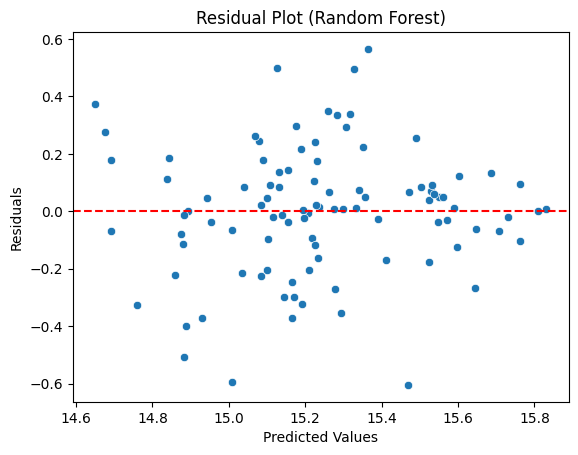

PCA Adjusted Ridge Regression MSE: 0.05042016863386066
PCA Adjusted Ridge Regression R^2 Score: 0.6136599974926158
Enter the details of the house:


In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
data = pd.read_csv('Housing.csv')

# 2. Encode Categorical Columns
label_encoder = LabelEncoder()
categorical_columns = [
    'mainroad', 'guestroom', 'basement', 'hotwaterheating',
    'airconditioning', 'prefarea', 'furnishingstatus'
]
for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

# 3. Remove Outliers
data = data[data['area'] < data['area'].quantile(0.95)]
data = data[data['price'] < data['price'].quantile(0.95)]

# 4. Transform Target Variable (Optional)
sns.histplot(data['price'], kde=True)
plt.title("Price Distribution Before Transformation")
plt.show()

# Log-transform target variable if highly skewed
data['price'] = np.log1p(data['price'])
sns.histplot(data['price'], kde=True)
plt.title("Price Distribution After Transformation")
plt.show()

# 5. Split Features and Target
X = data.drop(columns=['price'])
y = data['price']

# 6. Scale Numerical Features
scaler = StandardScaler()
numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# 7. Add Polynomial Features
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X)

# 8. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# 9. Hyperparameter Tuning for Ridge Regression
param_grid = {'alpha': [0.1, 1, 10, 100, 1000]}
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)

best_alpha = grid_search.best_params_['alpha']
print(f"Best Alpha for Ridge Regression: {best_alpha}")

# Train Ridge Model with Best Alpha
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate Ridge Model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge Regression MSE: {mse_ridge}")
print(f"Ridge Regression R^2 Score: {r2_ridge}")

# 10. Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest Model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest MSE: {mse_rf}")
print(f"Random Forest R^2 Score: {r2_rf}")

# 11. Feature Importance Analysis (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': poly.get_feature_names_out(X.columns),
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance from Random Forest:\n", feature_importance.head())

sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Feature Importance")
plt.show()

# 12. Residual Analysis
residuals = y_test - y_pred_rf
sns.scatterplot(x=y_pred_rf, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (Random Forest)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

# 13. PCA for Dimensionality Reduction (Optional)
from sklearn.decomposition import PCA

pca = PCA(n_components=10)  # Adjust components based on variance explained
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

ridge_model.fit(X_train_pca, y_train)
y_pred_pca = ridge_model.predict(X_test_pca)

mse_pca = mean_squared_error(y_test, y_pred_pca)
r2_pca = r2_score(y_test, y_pred_pca)
print(f"PCA Adjusted Ridge Regression MSE: {mse_pca}")
print(f"PCA Adjusted Ridge Regression R^2 Score: {r2_pca}")

# 14. Predict for a New House
def predict_house_price():
    print("Enter the details of the house:")
    area = float(input("Area (in square feet): "))
    bedrooms = int(input("Number of bedrooms: "))
    bathrooms = int(input("Number of bathrooms: "))
    stories = int(input("Number of stories: "))
    mainroad = int(input("Main road access (1 for yes, 0 for no): "))
    guestroom = int(input("Guestroom available (1 for yes, 0 for no): "))
    basement = int(input("Basement available (1 for yes, 0 for no): "))
    hotwaterheating = int(input("Hot water heating available (1 for yes, 0 for no): "))
    airconditioning = int(input("Air conditioning available (1 for yes, 0 for no): "))
    parking = int(input("Number of parking spaces: "))
    prefarea = int(input("Preferred area (1 for yes, 0 for no): "))
    furnishingstatus = int(input("Furnishing status (0 for unfurnished, 1 for semi-furnished, 2 for furnished): "))

    # Create a DataFrame for the input
    input_data = pd.DataFrame([[
        area, bedrooms, bathrooms, stories, mainroad, guestroom, basement,
        hotwaterheating, airconditioning, parking, prefarea, furnishingstatus
    ]], columns=[
        'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
        'basement', 'hotwaterheating', 'airconditioning', 'parking',
        'prefarea', 'furnishingstatus'
    ])

    # Scale and add polynomial features
    input_data[numerical_cols] = scaler.transform(input_data[numerical_cols])
    input_data_poly = poly.transform(input_data)

    # Predict using Random Forest
    predicted_price_rf = rf_model.predict(input_data_poly)[0]
    print(f"\nPredicted House Price (Random Forest): ₹{np.expm1(predicted_price_rf):,.2f}")

predict_house_price()

# Evaluate Random Forest Model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest MSE: {mse_rf}")
print(f"Random Forest R^2 Score: {r2_rf}")

# Transform predictions and actual values back to the original scale
y_test_original = np.expm1(y_test)  # Inverse of np.log1p
y_pred_rf_original = np.expm1(y_pred_rf)

# Plot Actual vs. Predicted Values in Original Scale
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_original, y=y_pred_rf_original)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.title("Actual vs. Predicted House Prices (Original Scale)")
plt.xlabel("Actual Prices (₹)")
plt.ylabel("Predicted Prices (₹)")
plt.legend()
plt.show()

# Numerical Comparison
comparison = pd.DataFrame({
    'Actual Price (₹)': y_test_original[:10],
    'Predicted Price (₹)': y_pred_rf_original[:10]
}).round(2)

print("\nComparison of Actual and Predicted Prices:\n")
print(comparison)


